2. LSTM & CNN 조합 이용해 영화 리뷰 만들기

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Activation, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8011 - loss: 0.4044 - val_accuracy: 0.8848 - val_loss: 0.2881
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9083 - loss: 0.2356 - val_accuracy: 0.8923 - val_loss: 0.2631
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.9319 - loss: 0.1838 - val_accuracy: 0.8846 - val_loss: 0.2839
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.9450 - loss: 0.1519 - val_accuracy: 0.8904 - val_loss: 0.2785
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - accuracy: 0.9575 - loss: 0.1189 - val_accuracy: 0.8926 - val_loss: 0.3088
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8830 - loss: 0.3320

 Test Accuracy: 0.8830


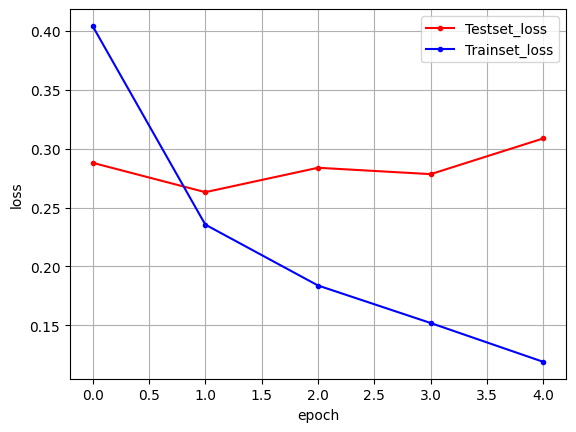

In [3]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words = 5000)
X_train = sequence.pad_sequences(X_train, maxlen = 500)
X_test = sequence.pad_sequences(X_test, maxlen = 500)

model = Sequential()
model.add(Embedding(5000, 100))
model.add(Dropout(0.5))
model.add(Conv1D(64, 5, padding = 'valid', activation = 'relu', strides = 1))
model.add(MaxPooling1D(pool_size = 4))
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 3)
history = model.fit(X_train, y_train, batch_size = 40, epochs = 100, validation_split = 0.25, callbacks = [early_stopping_callback])

print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker = '.', c = 'red', label = 'Testset_loss')
plt.plot(x_len, y_loss, marker = '.', c = 'blue', label = 'Trainset_loss')

plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

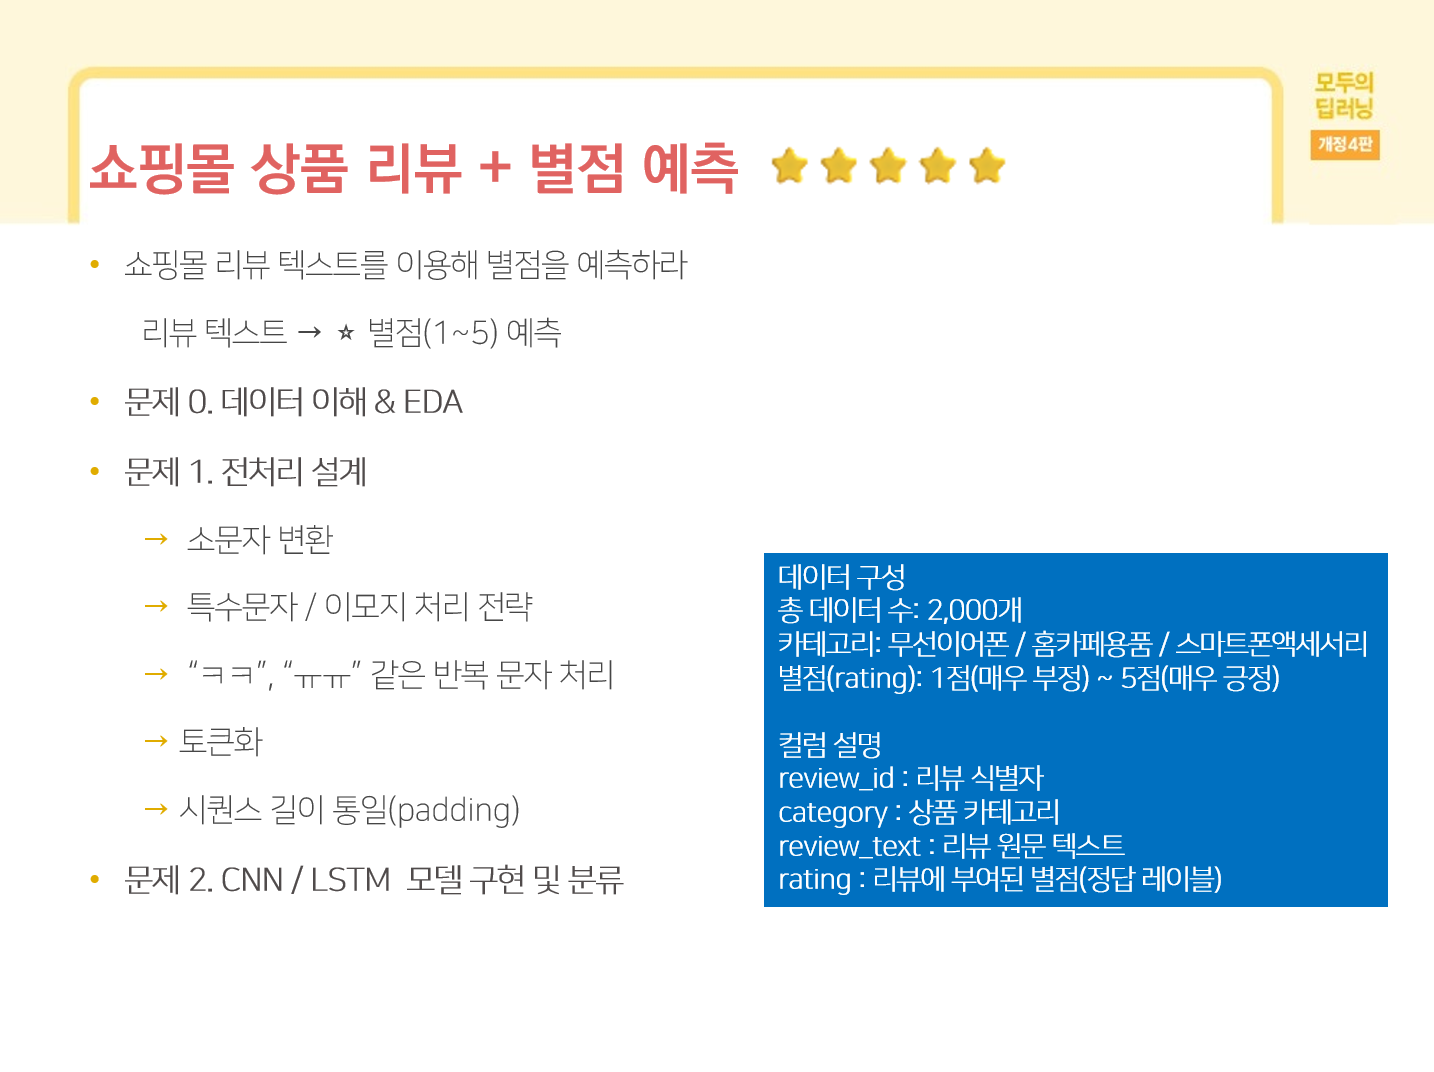

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# 운영체제에 맞는 한글 폰트를 설정해야 그래프에서 한글이 깨지지 않습니다.
plt.rc('font', family='NanumGothic') # 예시: 나눔고딕
plt.rcParams['axes.unicode_minus'] = False

In [13]:
df = pd.read_csv('./data/naver_style_reviews_2000_diverse.csv')
df

,review_id,category,review_text,rating
0,1,무선이어폰,무난하게 좋음해서 샀는데 출퇴근에 써보니 디 ㅋㅋ 헐 자인 예쁘고 배터리 오래가고...,4
1,2,홈카페용품,무난 … . 설거지 덜 하고 밸런스가 애매하고. 호불호 있을 듯,3
2,3,스마트폰액세서리,진짜 레전드해서 샀는데 여행에 😊 써보니 딱 내 취향이고 자석 힘 솔직히 세고....,5
3,4,무선이어폰,괜찮아요. 마이 ㅠㅠ 크 생각보다 좋고. 가격 생각하면 굿 😊,4
4,5,스마트폰액세서리,아쉽해서샀는데 차 안에 써보니 맥세이프 약하고 초기 ㅜㅜ 불량이라. 좋네 느낌. 재...,2
...,...,...,...,...
1995,1996,홈카페용품,이건 찐이다해서 샀는데 퇴근 후에 써보니 크레마 잘 올라오고 선물용으로도 좋고. 가...,5
1996,1997,홈카페용품,별로해서 샀는데 손님 올 때에 써보니 향이 인위적 ㄹㅇ 이고 세척이 귀찮고 그래도 ...,2
1997,1998,무선이어폰,대만족. 착용감 편하고. 강추 !,5
1998,1999,홈카페용품,! 진짜 만족 🔥 해서 샀는데 홈카페에 써보니 아로마가 살아있고 선물용으로도 좋고....,5


In [17]:
print(df.info())
print('------------------')
print(df['category'].unique())
print('------------------')
print(df['rating'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    2000 non-null   int64
 1   category     2000 non-null   str  
 2   review_text  2000 non-null   str  
 3   rating       2000 non-null   int64
dtypes: int64(2), str(2)
memory usage: 62.6 KB
None
------------------
<StringArray>
['무선이어폰', '홈카페용품', '스마트폰액세서리']
Length: 3, dtype: str
------------------
[4 3 5 2 1]


In [ ]:
def clean_text(text):
    # 1. 이모지 삭제 (유니코드 범위를 기반으로 삭제)
    text = text.encode('cp949', 'ignore').decode('cp949') # 윈도우 환경 등에서 이모지 깨짐 방지
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    # 2 & 3. 반복 문자 및 특수문자 처리
    # ㅋㅋ, ㅎㅎ, ㅜㅜ, ㅠㅠ 등의 반복 처리
    text = re.sub(r'[ㄱ-ㅎㅏ-ㅣ]+', '', text) # 자음/모음만 있는 경우 삭제
    # 특수문자 삭제 (한글, 영문, 숫자, 공백 제외하고 삭제)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text)
    # 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [27]:
# 정제 함수 적용
df['review_text'] = df['review_text'].fillna('')
df['cleaned_review'] = df['review_text'].apply(clean_text)

print("--- 정제 전 ---")
print(df['review_text'].iloc[0])
print("\n--- 정제 후 ---")
print(df['cleaned_review'].iloc[0])

--- 정제 전 ---
무난하게 좋음해서 샀는데 출퇴근에 써보니 디 ㅋㅋ  헐 자인 예쁘고 배터리 오래가고. 레전드 느낌. 가격 생각하면 굿

--- 정제 후 ---
무난하게 좋음해서 샀는데 출퇴근에 써보니 디 헐 자인 예쁘고 배터리 오래가고 레전드 느낌 가격 생각하면 굿


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

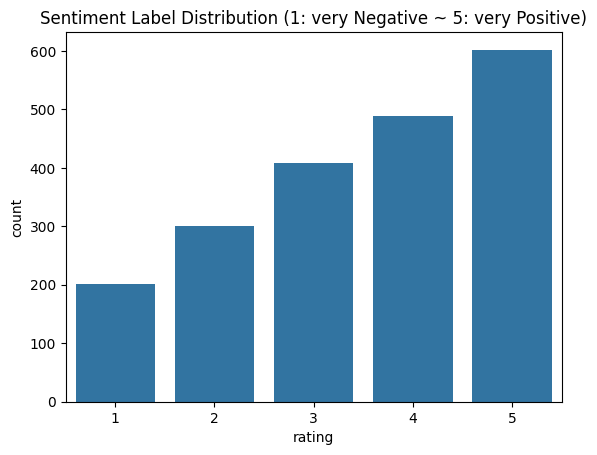

In [32]:
sns.countplot(x='rating', data=df)
plt.title('Sentiment Label Distribution (1: very Negative ~ 5: very Positive)')
plt.show()

In [33]:
# EDA 결과를 바탕으로 최대 길이 설정 (예: 100)
max_len = 100
vocab_size = 5000

# 단어 사전 구축
tokenizer = Tokenizer(num_words = vocab_size)
tokenizer.fit_on_texts(df['cleaned_review'])

# 텍스트를 시퀀스(숫자 리스트)로 변환
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# 단어 사전 크기 확인
vocab_size = len(tokenizer.word_index) + 1
print(f"단어 사전 크기: {vocab_size}")

단어 사전 크기: 734


In [34]:
# padding='pre'는 앞을 0으로 채우고, 'post'는 뒤를 채웁니다.
X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
y = df['rating'].values

print(f"패딩 후 데이터 형태: {X_padded.shape}")
print(f"첫 번째 데이터 예시:\n{X_padded[0]}")

패딩 후 데이터 형태: (2000, 100)
첫 번째 데이터 예시:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0  59  52   3 125   1 362
  30 416  29  83 160  41   2  53  60  57]


In [36]:
# CNN + LSTM 모델 설계 및 학습
model = Sequential([
    Embedding(vocab_size, 100, input_length=max_len),
    Dropout(0.3),
    Conv1D(64, 5, activation='relu'), # 텍스트 지역 특징 추출
    MaxPooling1D(pool_size=4),
    LSTM(64), # 맥락 정보 학습
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3)

print("\n--- 모델 학습 시작 ---")
history = model.fit(X_padded, y, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop])


--- 모델 학습 시작 ---
Epoch 1/10


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1013 - loss: -15.1112 - val_accuracy: 0.0975 - val_loss: -26.7882
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1013 - loss: -31.8166 - val_accuracy: 0.0975 - val_loss: -37.2023
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1013 - loss: -41.3925 - val_accuracy: 0.0975 - val_loss: -46.4785
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1013 - loss: -50.2952 - val_accuracy: 0.0975 - val_loss: -55.2896
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1013 - loss: -58.9156 - val_accuracy: 0.0975 - val_loss: -63.9164
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1013 - loss: -67.4018 - val_accuracy: 0.0975 - val_loss: -72.3951
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1013 - loss: -75.7661 - val_accuracy: 0.0975 - val_loss: -80.8905
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1013 - loss: -84.1138 - val_accuracy

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

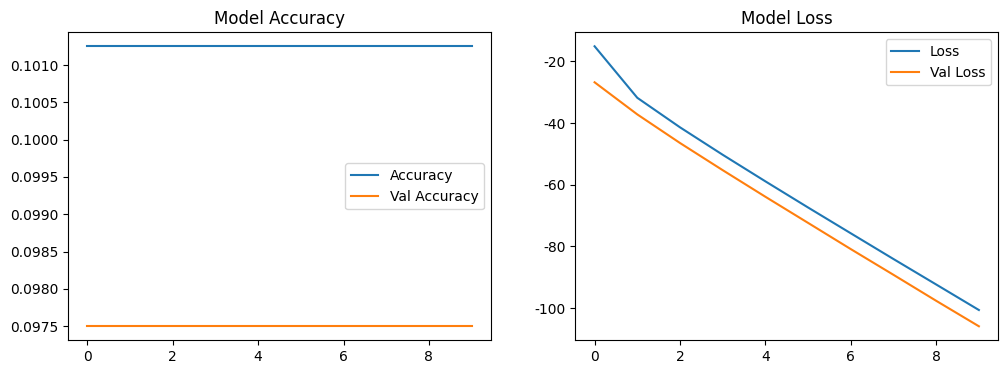

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

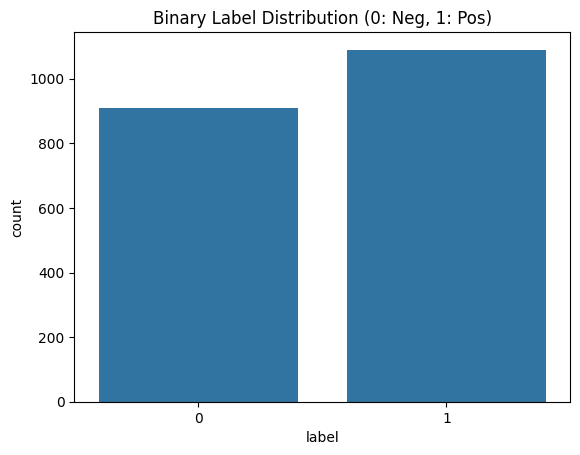

패딩 후 데이터 형태: (2000, 100)
라벨 데이터 형태: (2000,)

--- 모델 학습 시작 ---
Epoch 1/15


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6231 - loss: 0.6408 - val_accuracy: 0.8525 - val_loss: 0.5003
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9619 - loss: 0.2352 - val_accuracy: 0.9925 - val_loss: 0.0837
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9875 - loss: 0.0635 - val_accuracy: 0.9925 - val_loss: 0.0559
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9887 - loss: 0.0455 - val_accuracy: 0.9875 - val_loss: 0.0551
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9906 - loss: 0.0332 - val_accuracy: 0.9875 - val_loss: 0.0546
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9944 - loss: 0.0235 - val_accuracy: 0.9850 - val_loss: 0.0622
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9950 - loss: 0.0186 - val_accuracy: 0.9900 - val_loss: 0.0602
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9969 - loss: 0.0140 - val_accuracy: 0.9875 - val_loss: 0.

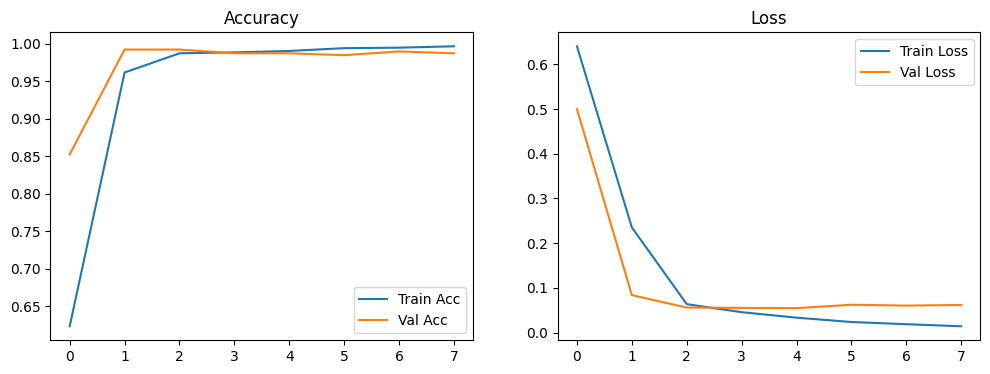

In [47]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. 데이터 로드
df = pd.read_csv('./data/naver_style_reviews_2000_diverse.csv')

# 2. 라벨 전처리 (가장 중요!)
# rating이 4, 5면 긍정(1), 1, 2면 부정(0)으로 변환합니다. (3점 중립은 보통 제거하여 성능을 높입니다)
# df = df[df['rating'] != 3] 
df['label'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

# 3. 텍스트 정제 함수
def clean_text(text):
    if not isinstance(text, str): return ""
    # 특수문자 및 자음/모음 제거 (re 활용)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text) # 한글, 영문, 숫자만 남김
    text = re.sub(r'[ㄱ-ㅎㅏ-ㅣ]+', '', text) # ㅋㅋ, ㅠㅠ 제거
    text = re.sub(r'\s+', ' ', text).strip() # 중복 공백 제거
    return text

df['cleaned_review'] = df['review_text'].fillna('').apply(clean_text)

# 4. EDA (분포 확인)
sns.countplot(x='label', data=df)
plt.title('Binary Label Distribution (0: Neg, 1: Pos)')
plt.show()

# 5. 토큰화 및 패딩
vocab_size = 5000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# 단어 사전 크기 재설정 (실제 단어 수와 vocab_size 중 작은 값 사용)
actual_vocab_size = min(len(tokenizer.word_index) + 1, vocab_size)

X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
y = df['label'].values # 평점 대신 변환한 label 사용

print(f"패딩 후 데이터 형태: {X_padded.shape}")
print(f"라벨 데이터 형태: {y.shape}")

# 6. CNN + LSTM 모델 설계
model = Sequential([
    # 실제 단어 사전 크기를 반영
    Embedding(actual_vocab_size, 128, input_length=max_len),
    Dropout(0.3),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=4),
    LSTM(64),
    Dense(1, activation='sigmoid') # 0~1 사이의 확률값 출력
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 7. 모델 학습
print("\n--- 모델 학습 시작 ---")
history = model.fit(
    X_padded, y, 
    epochs=15, 
    batch_size=64, 
    validation_split=0.2, 
    callbacks=[early_stop]
)

# 8. 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [50]:
import re
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 레이블링 (이전과 동일)
df = pd.read_csv('./data/naver_style_reviews_2000_diverse.csv')
df = df[df['rating'] != 3] # 3점은 제외
df['label'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

# 2. 전처리 함수 수정 (중요!)
def clean_text_v2(text):
    if not isinstance(text, str): return ""
    # 이모지 제거
    text = re.sub(r'[^\x00-\x7F가-힣]', '', text)
    # 특수문자 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text)
    # ★ㅋㅋ, ㅠㅠ 등은 제거하지 않고 특수 토큰으로 변경하거나 내버려두는 게 문맥 이해에 더 좋을 수 있습니다.
    # 일단은 반복되는 자음/모음만 정제합니다.
    text = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', text) # 예: ㅋㅋㅋ -> ㅋㅋ
    
    # 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_review'] = df['review_text'].fillna('').apply(clean_text_v2)

# 3. 토큰화 및 패딩
vocab_size = 5000
max_len = 100
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
y = df['label'].values

# 4. 모델 재설계 (더 정교한 학습)
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Dropout(0.3), # 과적합 방지
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=4),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 5. 재학습
history = model.fit(X_padded, y, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop])

# 6. 다시 예측 테스트
def predict_sentiment_v2(new_sentence, model, tokenizer):
    cleaned = clean_text_v2(new_sentence)
    encoded = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(encoded, maxlen=100, padding='pre')
    score = float(model.predict(padded)[0][0])
    
    if score > 0.5:
        print(f"'{new_sentence}' -> 긍정 리뷰 ({score*100:.2f}% 확률)")
    else:
        print(f"'{new_sentence}' -> 부정 리뷰 ({(1-score)*100:.2f}% 확률)")

print("\n--- 실제 데이터 예측 테스트 (재학습 후) ---")
test_reviews = [
    "배송이 정말 빠르고 제품도 튼튼해서 너무 만족해요!",
    "퀄리티가 너무 낮고 금방 고장났어요. 다시는 안 삽니다.",
    "그냥저냥 쓸만해요. ㅋㅋㅋ",
    "포장이 너무 허술해서 제품이 다 찌그러져서 왔네요."
]

for review in test_reviews:
    predict_sentiment_v2(review, model, tokenizer)

Epoch 1/10


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6881 - loss: 0.5637 - val_accuracy: 0.9122 - val_loss: 0.3209
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0933 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9961 - loss: 0.0132 - val_accuracy: 0.9969 - val_loss: 0.0050
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9969 - val_loss: 0.0046
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 5.4171e-04 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 4.2563e-04 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 2.9353e-04 - val_accuracy: 1.0000 - 

In [48]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

model.save('sentiment_model.h5')
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

def predict_sentiment(new_sentence, model, tokenizer, max_len=100):
    # A. 텍스트 전처리 (학습 시와 동일한 전처리 필요)
    # 특수문자 및 자음/모음 제거
    cleaned_sentence = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', new_sentence)
    cleaned_sentence = re.sub(r'[ㄱ-ㅎㅏ-ㅣ]+', '', cleaned_sentence)
    cleaned_sentence = re.sub(r'\s+', ' ', cleaned_sentence).strip()
    
    # B. 토큰화 및 시퀀스 변환
    encoded = tokenizer.texts_to_sequences([cleaned_sentence])
    
    # C. 패딩
    padded = pad_sequences(encoded, maxlen=max_len, padding='pre')
    
    # D. 예측
    score = float(model.predict(padded)[0][0])
    
    # E. 결과 출력
    if score > 0.5:
        print(f"'{new_sentence}' -> 긍정 리뷰 ({score*100:.2f}% 확률)")
    else:
        print(f"'{new_sentence}' -> 부정 리뷰 ({(1-score)*100:.2f}% 확률)")

model = load_model('sentiment_model.h5')
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

print("\n--- 실제 데이터 예측 테스트 ---")
test_reviews = [
    "배송이 정말 빠르고 제품도 튼튼해서 너무 만족해요!",
    "퀄리티가 너무 낮고 금방 고장났어요. 다시는 안 삽니다.",
    "그냥저냥 쓸만해요. ㅋㅋㅋ",
    "포장이 너무 허술해서 제품이 다 찌그러져서 왔네요."
]

for review in test_reviews:
    predict_sentiment(review, model, tokenizer)


--- 실제 데이터 예측 테스트 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
'배송이 정말 빠르고 제품도 튼튼해서 너무 만족해요!' -> 부정 리뷰 (93.54% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
'퀄리티가 너무 낮고 금방 고장났어요. 다시는 안 삽니다.' -> 부정 리뷰 (98.14% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
'그냥저냥 쓸만해요. ㅋㅋㅋ' -> 부정 리뷰 (95.52% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
'포장이 너무 허술해서 제품이 다 찌그러져서 왔네요.' -> 부정 리뷰 (91.34% 확률)
